# Exploratory Data Analysis (EDA) on the Titanic Dataset

##  Import libraries¶

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Titanic dataset

In [3]:

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


##   Display the first 5 rows


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##  Check number of rows and columns


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


## Display the last 5 rows

In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


## Display column names

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## Display dataset information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Basic statistical summary

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Check missing values in each column

In [10]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


##  Data Cleaning

In [11]:
# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


## Visualize missing values

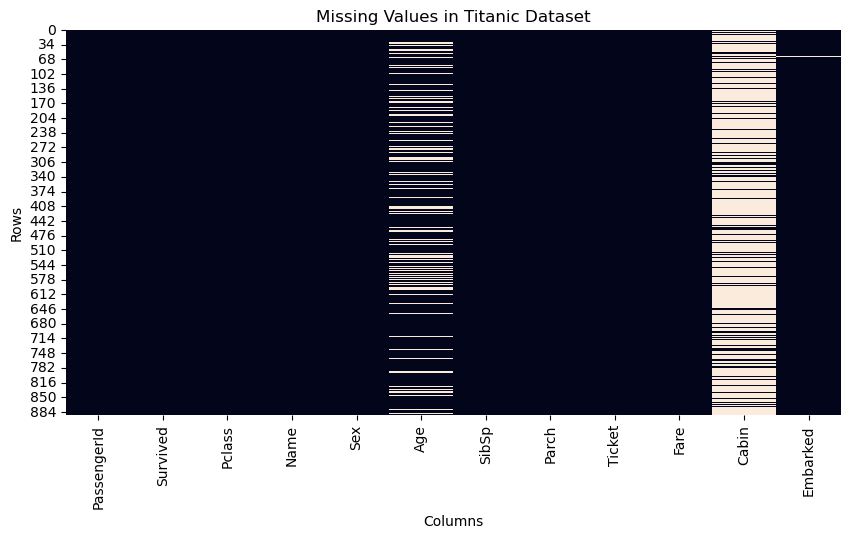

In [12]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

## Check duplicate rows


In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## Check data types of all columns

In [14]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

## Fill missing Age values with the median

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

### 3.2 Handle Missing Values

In [16]:
# Fill missing Embarked values with the mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [17]:
# Create a feature indicating whether cabin information is available

df["Cabin_Available"] = df["Cabin"].notnull().astype(int)

In [18]:
# Remove Cabin column after extracting useful information

df.drop("Cabin", axis=1, inplace=True)

In [19]:
# Check missing values after cleaning

df.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Cabin_Available    0
dtype: int64

## Statistical summary of numerical columns

In [20]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_Available
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,0.228956
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,0.420397
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


## 4. Basic Statistical Analysis

In [21]:
# Find median of numerical columns

df.median(numeric_only=True)

PassengerId        446.0000
Survived             0.0000
Pclass               3.0000
Age                 28.0000
SibSp                0.0000
Parch                0.0000
Fare                14.4542
Cabin_Available      0.0000
dtype: float64

## Find mode of each column


In [22]:
df.mode().iloc[0]

PassengerId                          1
Survived                           0.0
Pclass                             3.0
Name               Abbing, Mr. Anthony
Sex                               male
Age                               28.0
SibSp                              0.0
Parch                              0.0
Ticket                            1601
Fare                              8.05
Embarked                             S
Cabin_Available                    0.0
Name: 0, dtype: object

In [23]:
# Number of unique values in each column

df.nunique()

PassengerId        891
Survived             2
Pclass               3
Name               891
Sex                  2
Age                 88
SibSp                7
Parch                7
Ticket             681
Fare               248
Embarked             3
Cabin_Available      2
dtype: int64

In [24]:
# Count survived and non-survived passengers

survival_count = df["Survived"].value_counts()

print(survival_count)

Survived
0    549
1    342
Name: count, dtype: int64


##  Univariate Analysis

In [25]:
# Calculate survival percentage

survival_percentage = df["Survived"].value_counts(normalize=True) * 100

print(survival_percentage)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


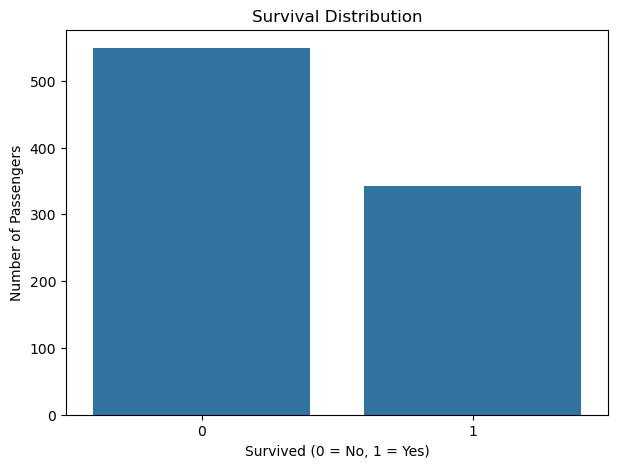

In [26]:
# Visualize survival distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [27]:
# Count passengers by gender

print(df["Sex"].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


###  Gender Distribution

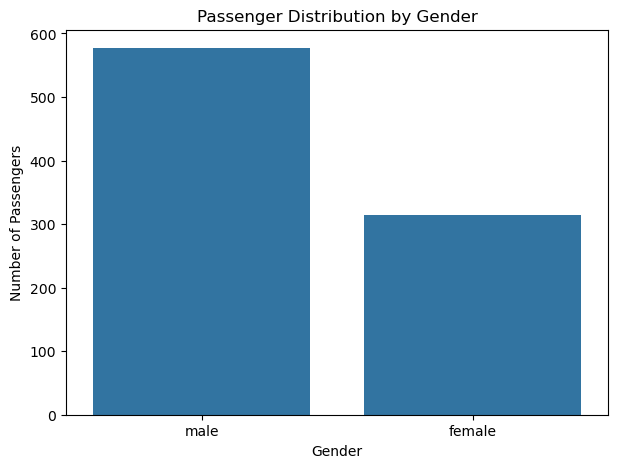

In [28]:
# Gender distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex")

plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

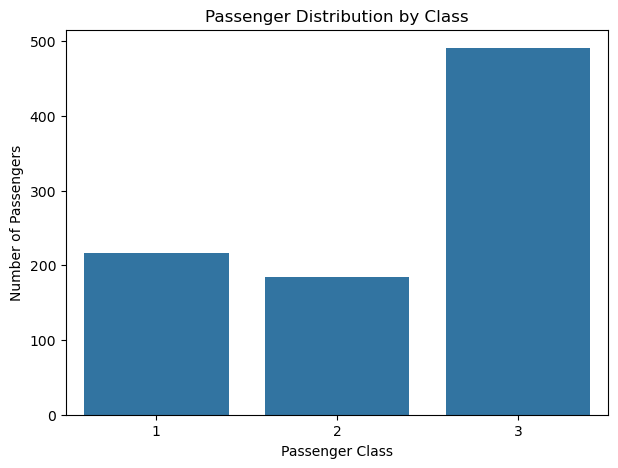

In [29]:
# Passenger class distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

###  Passenger Class Distribution

In [30]:
# Survival count by gender

pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


##  Bivariate Analysis 

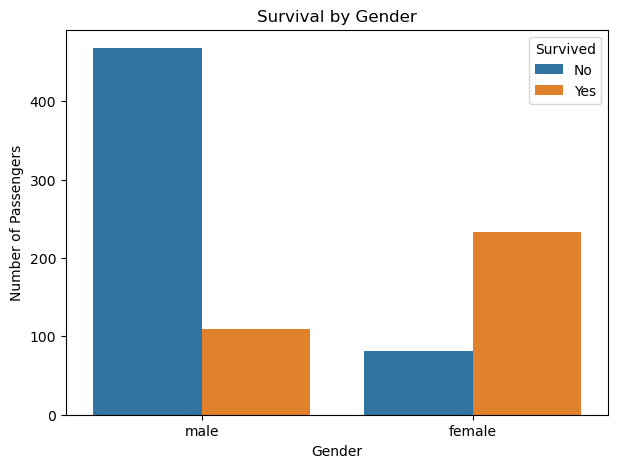

In [31]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

In [32]:
# Survival rate by gender

gender_survival = df.groupby("Sex")["Survived"].mean() * 100

print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


In [33]:
# Survival count by passenger class

pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


###  Survival by Passenger Class

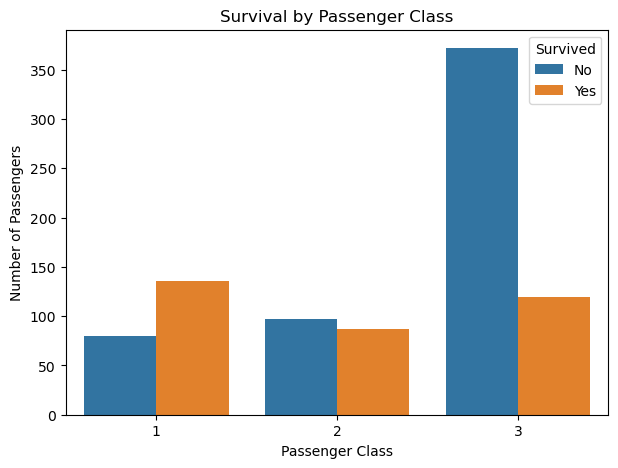

In [34]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

In [35]:
# Survival rate by passenger class

class_survival = df.groupby("Pclass")["Survived"].mean() * 100

print(class_survival)

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


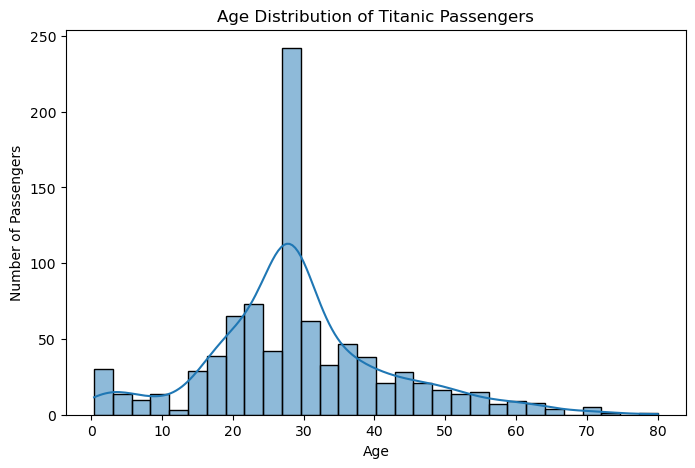

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

###  Age Distribution

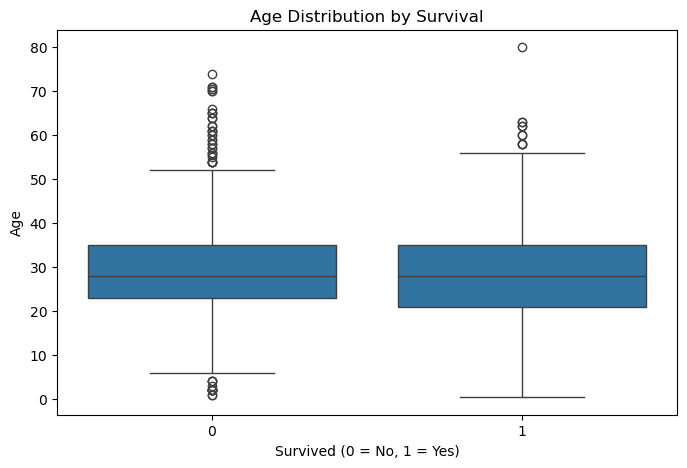

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Survived", y="Age")

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

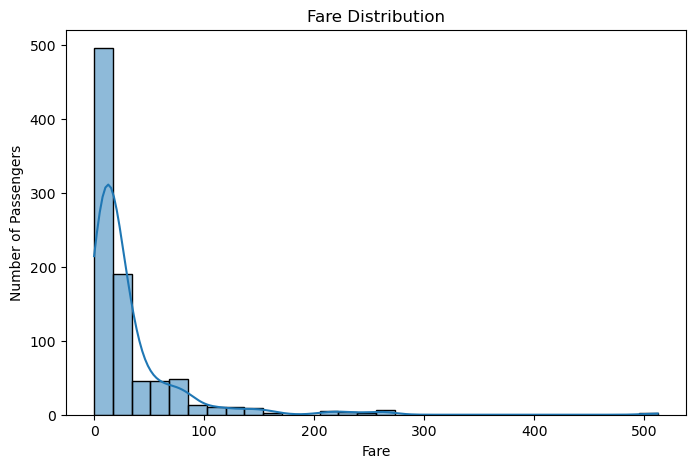

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

###  Fare Distribution

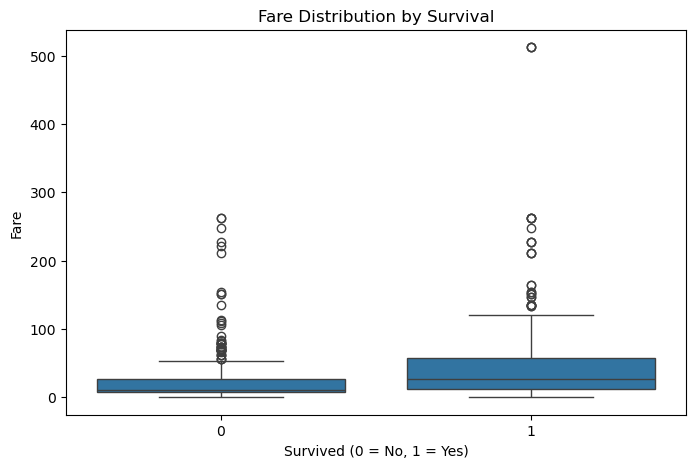

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Survived", y="Fare")

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

In [40]:
# Create FamilySize feature

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


###  Family Size

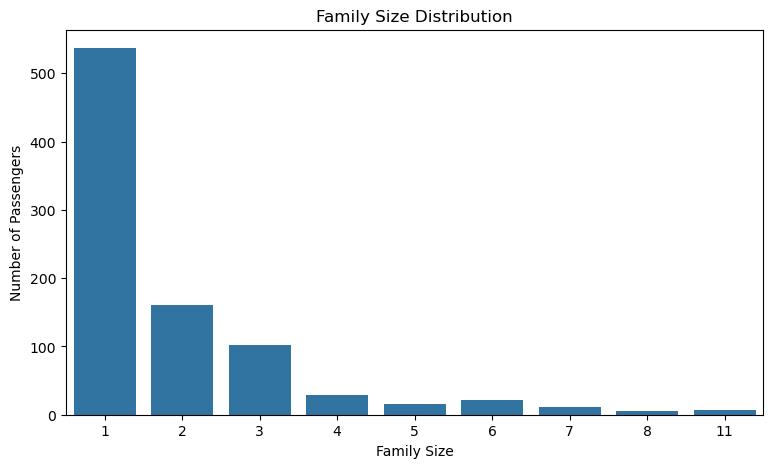

In [41]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="FamilySize")

plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

plt.show()

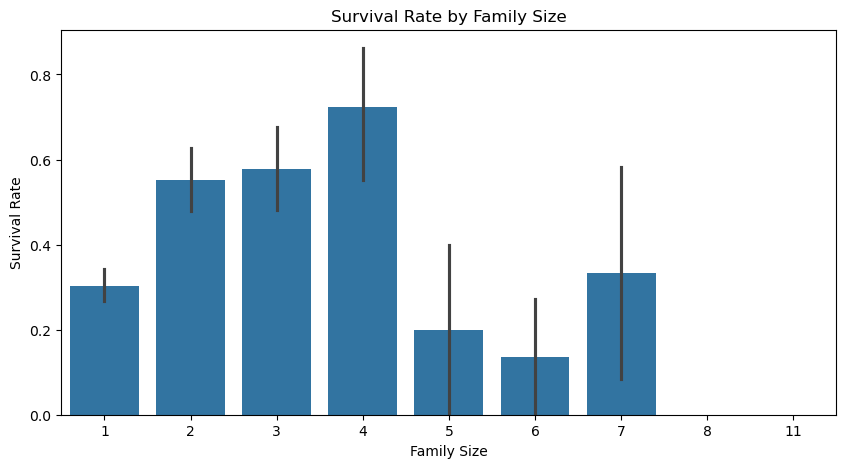

In [42]:
plt.figure(figsize=(10, 5))

sns.barplot(data=df, x="FamilySize", y="Survived")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

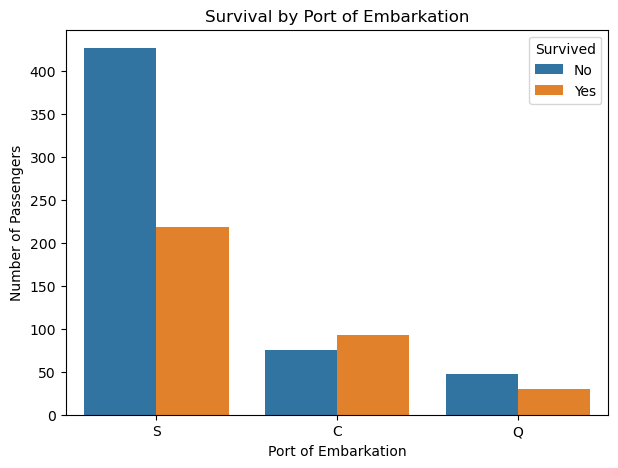

In [43]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Embarked", hue="Survived")

plt.title("Survival by Port of Embarkation")
plt.xlabel("Port of Embarkation")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

###  Survival by Port of Embarkation

In [44]:
# Select numerical columns for correlation analysis

numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

correlation = df[numeric_columns].corr()

correlation

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
FamilySize,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


##  Correlation Analysis

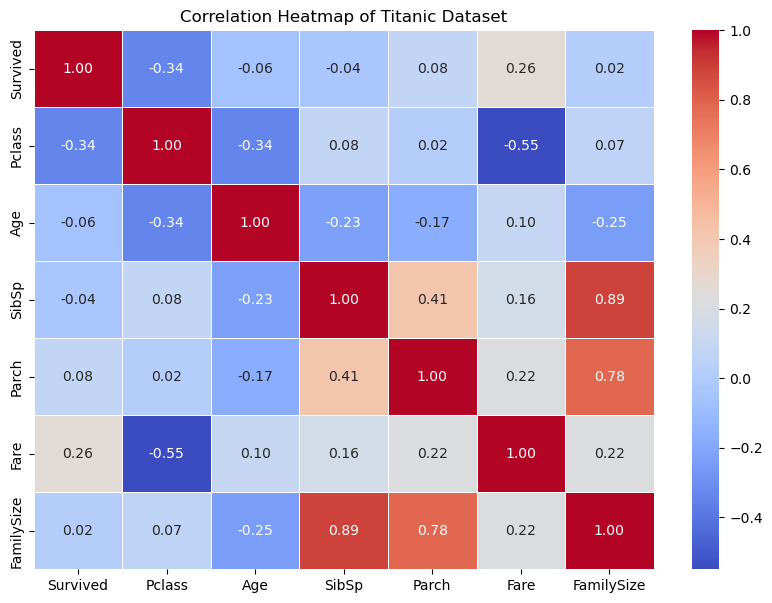

In [45]:
# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Titanic Dataset")

plt.show()

In [46]:
# Overall survival rate

overall_survival_rate = df["Survived"].mean() * 100

print(f"Overall Survival Rate: {overall_survival_rate:.2f}%")

Overall Survival Rate: 38.38%


##  Combined Analysis

In [47]:
# Survival rate by gender and passenger class

survival_gender_class = df.groupby(
    ["Sex", "Pclass"]
)["Survived"].mean() * 100

print(survival_gender_class)

Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64


###  Survival Rate by Gender and Class Combined

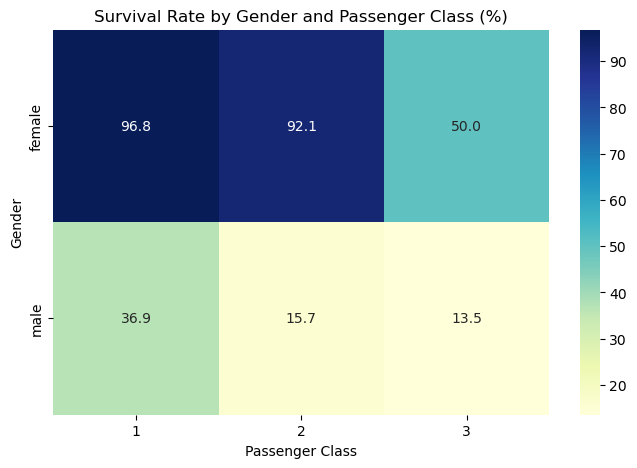

In [48]:
# Survival rate by gender and passenger class

pivot_table = df.pivot_table(
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
) * 100

plt.figure(figsize=(8, 5))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Survival Rate by Gender and Passenger Class (%)")
plt.xlabel("Passenger Class")
plt.ylabel("Gender")

plt.show()

## Conclusion
